# Dynamic Programming Evaluation & Control - Visualization
This notebook provides a dynamic, in-place animation of the different algorithms using Dynamic Programming in the tabular case to either Evaluate a policy or do Control. These are: Iterative Policy Evaluation, Value Iteration and Policy Iteration. It updates the grid dynamically, showing the evolution of the value function without iteration by iteration.

In [1]:
# Use these commands if your notebook is in a subfolder
#import sys
#import os
#sys.path.append(os.path.abspath('..'))

from IPython.display import display, clear_output
import time

from envs.maze_env import MazeEnv, UP, DOWN, LEFT, RIGHT
from algorithms.policy_evaluation import PolicyEvaluator
from algorithms.value_iteration import ValueIteration
from utils.visualization import plot_grid, plot_policy

In [4]:
# 1. Setup the environment
layout = [
    "S.....X",
    ".X.XX..",
    "XX.XX.X",
    "XX....G"
]

# 2. Define the reward function
REWARD_STEP = -1.0
REWARD_GOAL = 25.0
REWARD_WALL = -0.25

# Initialize the Maze
env = MazeEnv(layout, REWARD_STEP, REWARD_GOAL, REWARD_WALL)

# 3. Define discount factor
GAMMA = 0.95

# 4. Define our Stochastic Policy
# The policy is a dictionary mapping states to action probabilities.
policy = {}
for r in range(env.height):
    for c in range(env.width):
        if env.maze[r][c] not in ['X', 'G']:
            if r == 0:
                # Top row:
                policy[(r, c)] = {UP: 0.0, DOWN: 0.10, LEFT: 0.25, RIGHT: 0.65}
            else:
                # Everywhere else
                policy[(r, c)] = {UP: 0.05, DOWN: 0.15, LEFT: 0.3, RIGHT: 0.5}

In [5]:
# Evaluate the Policy and track explicitly how V(s) changes over time
evaluator = PolicyEvaluator(env, gamma=GAMMA)
final_V, history = evaluator.evaluate_policy(policy, return_history=True, verbose=False)

Policy evaluation converged after 124 iterations.


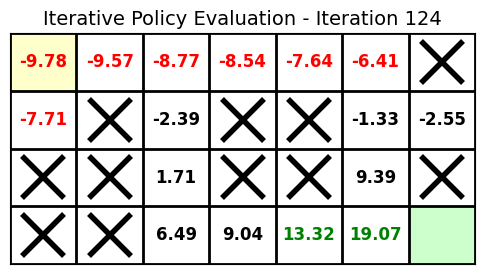

Finished run.


In [6]:
# Play an in-place animation that updates the same cell dynamically
step_size = 10  # We skip 10 frames at a time
algorithm = 'Policy Evaluation'

for i in range(0, len(history), step_size):
#for i in range(0,3):
    clear_output(wait=True)  # This deletes the previous plot before showing the new one
    plot_grid(env, algorithm, history[i], i)
    time.sleep(1.0)

# Guarantee the final converged state is printed at the very end
if (len(history) - 1) % step_size != 0:
    clear_output(wait=True)
    plot_grid(env, algorithm, history[-1], len(history) - 1)
    print("Finished run.")


In [7]:
# Find the optimal value function and track how V(s) changes across iterations
controller = ValueIteration(env, gamma=GAMMA)
optimal_V, history_opt = controller.value_iteration(return_history=True, verbose=False)
optimal_pi = controller.extract_optimal_policy()

Value iteration converged after 11 iterations.


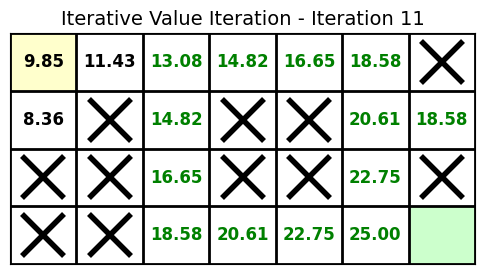

In [ ]:
# Play an in-place animation that updates the same cell dynamically
step_size = 1 
algorithm = 'Value Iteration'

for i in range(0, len(history_opt), step_size):
#for i in range(0,3):
    clear_output(wait=True)  # This deletes the previous plot before showing the new one
    plot_grid(env, algorithm, history_opt[i], i)
    time.sleep(1.0)

# Guarantee the final converged state is printed at the very end
if (len(history_opt) - 1) % step_size != 0:
    clear_output(wait=True)
    plot_grid(env, algorithm, history_opt[-1], len(history_opt) - 1)
    print("Finished run.")

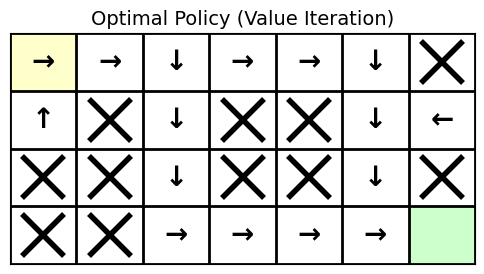

In [10]:
plot_policy(env, algorithm, optimal_pi)